In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset

In [2]:
dataset = load_dataset("windchimeran/GMRID")

In [3]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'Headline', 'Details', 'Severity', 'Region', 'Datetime', 'lat', 'lon', 'maritime_label', 'found_ports', 'contains_port_info', 'if_labeled', 'Headline_Details', 'Year', 'Month', 'Week', 'Details_cleaned', 'Category', 'Summarized_label', 'gpt-4o_label'],
        num_rows: 4594
    })
    test: Dataset({
        features: ['id', 'Headline', 'Details', 'Severity', 'Region', 'Datetime', 'lat', 'lon', 'maritime_label', 'found_ports', 'contains_port_info', 'if_labeled', 'Headline_Details', 'Year', 'Month', 'Week', 'Details_cleaned', 'Category', 'Summarized_label', 'gpt-4o_label'],
        num_rows: 1147
    })
})


In [4]:
print(dataset.keys())

dict_keys(['train', 'test'])


In [5]:
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

In [6]:
print(train_df.shape)
print(test_df.shape)
print(train_df.columns.tolist())

(4594, 20)
(1147, 20)
['id', 'Headline', 'Details', 'Severity', 'Region', 'Datetime', 'lat', 'lon', 'maritime_label', 'found_ports', 'contains_port_info', 'if_labeled', 'Headline_Details', 'Year', 'Month', 'Week', 'Details_cleaned', 'Category', 'Summarized_label', 'gpt-4o_label']


In [7]:
train_df.head()

,id,Headline,Details,Severity,Region,Datetime,lat,lon,maritime_label,found_ports,contains_port_info,if_labeled,Headline_Details,Year,Month,Week,Details_cleaned,Category,Summarized_label,gpt-4o_label
0,552,Severe winds caused brief suspension at Port o...,Local sources reported that operations at Pier...,Minor,South Africa,2018-12-28 05:15:00,-29.88386,31.01766,true,['durban'],true,true,Severe winds caused brief suspension at Port o...,2018,12,52,local source reported operation pier 1 2 conta...,Port Disruption,Weather,{}
1,933,"USA, California: Emergency personnel working t...",Information received states that emergency per...,Moderate,United States,2018-11-17 06:25:00,32.821,-117.153,false,['balboa'],true,false,"USA, California: Emergency personnel working t...",2018,11,46,information received state emergency personnel...,"Roadway Closure / Disruption, Non-industrial Fire",Administrative Issue,{}
2,2973,USA: 'Fridays for Future' climate change prote...,Protests against climate change are anticipate...,Minor,United States,2019-11-27 07:00:00,NaN,NaN,false,['new york'],true,false,USA: 'Fridays for Future' climate change prote...,2019,11,48,protest climate change anticipated nationwide ...,Protest / Riot,Worker Strike,{}
3,6,UPDATE - Indonesia: Severe winds damage infras...,Severe winds have downed billboards and trees ...,Moderate,Indonesia,2017-04-19 09:10:00,-6.91264,107.657,false,['jakarta'],true,true,UPDATE - Indonesia: Severe winds damage infras...,2017,4,16,severe wind downed billboard tree bandung wedn...,"Roadway Closure / Disruption, Flooding, Severe...",Weather,{}
4,4537,UPDATE 1 - Refrigerated container import capac...,Updated sources indicate that terminals at the...,Moderate,China,2020-02-03 21:57:00,38.98074,117.746,true,['tianjin'],true,true,UPDATE 1 - Refrigerated container import capac...,2020,2,6,updated source indicate terminal tianjin port ...,"Port Disruption, Cargo Disruption, Port Conges...",Administrative Issue,{}


In [8]:
# checking missing columns
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4594 entries, 0 to 4593
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id                  4594 non-null   int64
 1   Headline            4594 non-null   str  
 2   Details             4594 non-null   str  
 3   Severity            4594 non-null   str  
 4   Region              4594 non-null   str  
 5   Datetime            4594 non-null   str  
 6   lat                 3097 non-null   str  
 7   lon                 3097 non-null   str  
 8   maritime_label      4594 non-null   str  
 9   found_ports         4594 non-null   str  
 10  contains_port_info  4594 non-null   str  
 11  if_labeled          4593 non-null   str  
 12  Headline_Details    4593 non-null   str  
 13  Year                4594 non-null   int64
 14  Month               4594 non-null   int64
 15  Week                4594 non-null   int64
 16  Details_cleaned     4594 non-null   str  
 17  Catego

In [9]:
# unique count for each column
for col in train_df.columns:
    print(col, train_df[col].nunique())

id 4594
Headline 4529
Details 4594
Severity 4
Region 109
Datetime 4559
lat 2737
lon 2725
maritime_label 2
found_ports 507
contains_port_info 1
if_labeled 2
Headline_Details 4593
Year 4
Month 12
Week 53
Details_cleaned 4594
Category 723
Summarized_label 8
gpt-4o_label 1


category columns are severity , maritime_label , contain_port_info , if_labelled , summarized label and gpt-4o_label

In [10]:
train_df["Summarized_label"].value_counts()

Summarized_label
Administrative Issue    1417
Weather                 1390
Worker Strike            736
Accident                 665
Terrorism                322
Human Error               32
Others                    21
Cyber Attack              11
Name: count, dtype: int64

In [11]:
train_df["Category"].value_counts().head(50)

Category
Port Congestion                                                        563
Port Disruption                                                        406
Port Closure                                                           268
Maritime Advisory                                                      227
Maritime Accident                                                      201
Protest / Riot                                                         138
Industrial Fire                                                        104
Weather Advisory                                                       103
Miscellaneous Events                                                    98
Port Strike                                                             95
Miscellaneous Strikes                                                   90
Earthquake                                                              89
Cargo/Warehouse Theft                                                   79
Cargo Disruption

In [12]:
sorted(train_df["Summarized_label"].dropna().unique())

['Accident',
 'Administrative Issue',
 'Cyber Attack',
 'Human Error',
 'Others',
 'Terrorism',
 'Weather',
 'Worker Strike']

In [13]:
sorted(train_df["Category"].dropna().unique())[:100]

['Airline Incident / Crash',
 'Airline Incident / Crash, Flight Delays / Cancellations',
 'Airport Accident / Closure, Aviation Advisory, Explosion',
 'Airport Accident / Closure, Public Safety / Security, Hurricane, Severe Winds, Ground Transportation Advisory, Weather Advisory',
 'Aviation Advisory, Ground Transportation Advisory, Network Disruption, Maritime Advisory, Miscellaneous Events',
 'Aviation Advisory, Ground Transportation Advisory, Public Health Advisory, Maritime Advisory, Regulatory Advisory',
 'Aviation Advisory, Political Info / Event, Ground Transportation Advisory, Network Disruption, Maritime Advisory, Hurricane, Weather Advisory',
 'Aviation Advisory, Political Info / Event, Maritime Advisory, Miscellaneous Events',
 'Aviation Advisory,Ground Transportation Advisory',
 'Barge Accident',
 'Barge Accident,Waterway closure / Disruption',
 'Bomb Detonation / Explosion',
 'Bomb Detonation / Explosion, Hazmat Response',
 'Bomb Detonation / Explosion, Maritime Accident',

# 5. Define Risk Taxonomy

In [14]:
RISK_TAXONOMY = {
    "weather_disruption": {
        "name": "Weather Disruption",
        "description": (
            "Disruption to trade, transport, ports, logistics, or infrastructure "
            "caused by severe weather such as storms, flooding, high winds, "
            "cyclones, or similar weather-related hazards."
        )
    },

    "natural_disaster": {
        "name": "Natural Disaster",
        "description": (
            "Disruption caused by natural disasters such as earthquakes, "
            "tsunamis, volcanic activity, landslides, or other geological hazards."
        )
    },

    "port_operational_disruption": {
        "name": "Port Operational Disruption",
        "description": (
            "Disruption to normal port or cargo operations caused by congestion, "
            "capacity limitations, operational delays, cargo disruption, "
            "or reduced terminal efficiency."
        )
    },

    "port_closure": {
        "name": "Port Closure",
        "description": (
            "Full or partial closure, suspension, or shutdown of a port, terminal, "
            "pier, berth, or related maritime facility."
        )
    },

    "labor_strike_disruption": {
        "name": "Labor / Strike Disruption",
        "description": (
            "Disruption caused by worker strikes, industrial action, labor disputes, "
            "walkouts, or related workforce actions affecting transport or logistics."
        )
    },

    "maritime_security_navigation_disruption": {
        "name": "Maritime Security / Navigation Disruption",
        "description": (
            "Disruption or increased operational risk to maritime transport caused "
            "by piracy, maritime security threats, navigation restrictions, "
            "maritime advisories, or waterway disruption."
        )
    }
}

In [15]:
for risk_id, data in RISK_TAXONOMY.items():
    print(risk_id, "->", data["name"])

weather_disruption -> Weather Disruption
natural_disaster -> Natural Disaster
port_operational_disruption -> Port Operational Disruption
port_closure -> Port Closure
labor_strike_disruption -> Labor / Strike Disruption
maritime_security_navigation_disruption -> Maritime Security / Navigation Disruption


Build ground-truth mapping
For evaluation, you need a target label such as "true_risk" .
We'll derive it from GMRID's Category.

In [16]:
# Exact GMRID Category-to-taxonomy mapping. Ground truth remains category-derived only.
CATEGORY_TO_RISK = {
    # Weather
    "Weather Advisory": "weather_disruption",
    "Flooding": "weather_disruption",
    "Storm": "weather_disruption",
    "Tropical Cyclone / Storm": "weather_disruption",
    "Severe Winds": "weather_disruption",
    "Hurricane": "weather_disruption",
    "Typhoon": "weather_disruption",
    "Hail": "weather_disruption",
    "Tornado": "weather_disruption",

    # Natural disaster
    "Earthquake": "natural_disaster",
    "Landslide": "natural_disaster",

    # Port operations
    "Port Congestion": "port_operational_disruption",
    "Port Disruption": "port_operational_disruption",
    "Cargo Disruption": "port_operational_disruption",

    # Port closure
    "Port Closure": "port_closure",

    # Labour / strike
    "Port Strike": "labor_strike_disruption",
    "Cargo Transportation Strike": "labor_strike_disruption",
    "Miscellaneous Strikes": "labor_strike_disruption",
    "Industrial Action": "labor_strike_disruption",
    "General Strike": "labor_strike_disruption",
    "Civil Service Strike": "labor_strike_disruption",

    # Maritime security/navigation. Maritime Advisory is retained as a broad,
    # imperfect source proxy and is documented as such.
    "Maritime Advisory": "maritime_security_navigation_disruption",
    "Piracy": "maritime_security_navigation_disruption",
    "Waterway Closure / Disruption": "maritime_security_navigation_disruption",
}

RISK_ORDER = list(RISK_TAXONOMY)


In [17]:
def map_categories_to_risks(category_text):
    """Map exact GMRID Category tokens into a deterministic taxonomy-ordered list."""
    if pd.isna(category_text):
        return []

    categories = {category.strip() for category in str(category_text).split(",")}
    mapped = {CATEGORY_TO_RISK[category] for category in categories if category in CATEGORY_TO_RISK}
    return [risk_id for risk_id in RISK_ORDER if risk_id in mapped]


In [18]:
# apply the function to create "true_risk"
train_df["true_risks"] = train_df["Category"].apply(
    map_categories_to_risks
)

test_df["true_risks"] = test_df["Category"].apply(
    map_categories_to_risks
)

In [19]:
train_df[
    ["Category", "true_risks"]
].head(20)

,Category,true_risks
0,Port Disruption,[port_operational_disruption]
1,"Roadway Closure / Disruption, Non-industrial Fire",[]
2,Protest / Riot,[]
3,"Roadway Closure / Disruption, Flooding, Severe...",[weather_disruption]
4,"Port Disruption, Cargo Disruption, Port Conges...",[port_operational_disruption]
5,Weather Advisory,[weather_disruption]
6,"Protest / Riot, Ground Transportation Advisory",[]
7,"Cargo Disruption, Roadway Closure / Disruption...","[port_operational_disruption, maritime_securit..."
8,"Port Congestion, Cargo Disruption",[port_operational_disruption]
9,Port Congestion,[port_operational_disruption]


In [20]:
# remove rows where true_risk is empty
train_df["has_target_risk"] = train_df["true_risks"].apply(
    lambda x: len(x) > 0
)

test_df["has_target_risk"] = test_df["true_risks"].apply(
    lambda x: len(x) > 0
)

In [21]:
# dataset covered by risk taxonomy 
print(
    "Train covered:",
    train_df["has_target_risk"].sum(),
    "/",
    len(train_df)
)

print(
    "Test covered:",
    test_df["has_target_risk"].sum(),
    "/",
    len(test_df)
)

Train covered: 2916 / 4594
Test covered: 702 / 1147


In [22]:
# percentage dataset covered by risk taxonomy 
print(
    "Train coverage:",
    round(train_df["has_target_risk"].mean() * 100, 2),
    "%"
)

print(
    "Test coverage:",
    round(test_df["has_target_risk"].mean() * 100, 2),
    "%"
)

Train coverage: 63.47 %
Test coverage: 61.2 %


In [23]:
# Create POC datasets , filter to records that contain at least one of your six risks

train_poc = train_df[
    train_df["has_target_risk"]
].copy()

test_poc = test_df[
    test_df["has_target_risk"]
].copy()

In [24]:
# Reset indices
train_poc.reset_index(drop=True, inplace=True)
test_poc.reset_index(drop=True, inplace=True)

In [25]:
print(train_poc.shape)
print(test_poc.shape)

(2916, 22)
(702, 22)


In [26]:
train_poc.head()

,id,Headline,Details,Severity,Region,Datetime,lat,lon,maritime_label,found_ports,...,Headline_Details,Year,Month,Week,Details_cleaned,Category,Summarized_label,gpt-4o_label,true_risks,has_target_risk
0,552,Severe winds caused brief suspension at Port o...,Local sources reported that operations at Pier...,Minor,South Africa,2018-12-28 05:15:00,-29.88386,31.01766,true,['durban'],...,Severe winds caused brief suspension at Port o...,2018,12,52,local source reported operation pier 1 2 conta...,Port Disruption,Weather,{},[port_operational_disruption],True
1,6,UPDATE - Indonesia: Severe winds damage infras...,Severe winds have downed billboards and trees ...,Moderate,Indonesia,2017-04-19 09:10:00,-6.91264,107.657,false,['jakarta'],...,UPDATE - Indonesia: Severe winds damage infras...,2017,4,16,severe wind downed billboard tree bandung wedn...,"Roadway Closure / Disruption, Flooding, Severe...",Weather,{},[weather_disruption],True
2,4537,UPDATE 1 - Refrigerated container import capac...,Updated sources indicate that terminals at the...,Moderate,China,2020-02-03 21:57:00,38.98074,117.746,true,['tianjin'],...,UPDATE 1 - Refrigerated container import capac...,2020,2,6,updated source indicate terminal tianjin port ...,"Port Disruption, Cargo Disruption, Port Conges...",Administrative Issue,{},[port_operational_disruption],True
3,3771,Marine wind warning issued for Port of Sydney ...,Industry sources indicate that the Bureau of M...,Minor,Australia,2020-05-21 09:25:00,-33.97373,151.2168,false,['sydney'],...,Marine wind warning issued for Port of Sydney ...,2020,5,21,industry source indicate bureau meteorology is...,Weather Advisory,Weather,{},[weather_disruption],True
4,1947,Osaka’s G20 summit likely to impede logistics ...,Japan will host its first ever Group of Twenty...,Moderate,Japan,2019-06-21 15:21:00,34.43214,135.23035,false,"['kobe', 'osaka']",...,Osaka’s G20 summit likely to impede logistics ...,2019,6,25,japan host first ever group twenty g20 summit ...,"Cargo Disruption, Roadway Closure / Disruption...",Administrative Issue,{},"[port_operational_disruption, maritime_securit...",True


### Target Risk Distribution

The POC dataset contains six target risk classes and exhibits natural class imbalance.

`port_operational_disruption` is the most frequent class, while
`natural_disaster` and `labor_strike_disruption` are comparatively rare.

This imbalance is retained because Stage A uses deterministic rule-based
classification rather than a trained statistical classifier.

Class-level precision, recall, and F1-score will be evaluated separately so
that performance on less frequent risks is not hidden by the dominant class.

In [27]:
# checking class distribution for training data
train_label_counts = (
    train_poc["true_risks"]
    .explode()
    .value_counts()
)

train_label_counts

true_risks
port_operational_disruption                1394
maritime_security_navigation_disruption     464
weather_disruption                          435
labor_strike_disruption                     394
port_closure                                355
natural_disaster                            103
Name: count, dtype: int64

In [28]:
# checking class distribution for test data
test_label_counts = (
    test_poc["true_risks"]
    .explode()
    .value_counts()
)

test_label_counts

true_risks
port_operational_disruption                351
weather_disruption                         109
maritime_security_navigation_disruption     97
labor_strike_disruption                     89
port_closure                                85
natural_disaster                            35
Name: count, dtype: int64

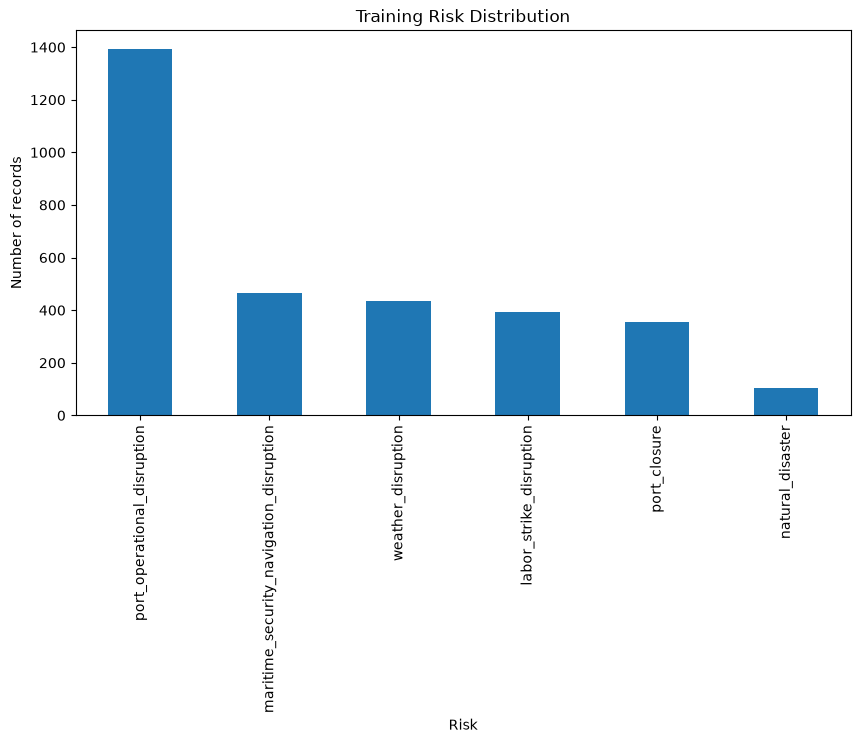

In [29]:
# count plot for class distribution 
train_label_counts.plot(
    kind="bar",
    title="Training Risk Distribution",
    figsize=(10, 5)
)

plt.ylabel("Number of records")
plt.xlabel("Risk")
plt.show()

### Text Fields

- `input_text`: Combined natural-language text from the event headline and details. It preserves the original wording and is used for semantic models, LLM input, and manual inspection.

- `normalized_text`: A lightly normalized version of `input_text`, mainly lowercased and whitespace-cleaned, used by Stage A for reliable keyword and phrase matching.

In [30]:
def prepare_text(row):
    """Build model input explicitly from the original headline and details."""
    headline = "" if pd.isna(row.get("Headline")) else str(row.get("Headline")).strip()
    details = "" if pd.isna(row.get("Details")) else str(row.get("Details")).strip()
    return " ".join(part for part in [headline, details] if part).strip()


In [31]:
# applying the function to the data
train_poc["input_text"] = train_poc.apply(
    prepare_text,
    axis=1
)

test_poc["input_text"] = test_poc.apply(
    prepare_text,
    axis=1
)

In [32]:
train_poc.head()

,id,Headline,Details,Severity,Region,Datetime,lat,lon,maritime_label,found_ports,...,Year,Month,Week,Details_cleaned,Category,Summarized_label,gpt-4o_label,true_risks,has_target_risk,input_text
0,552,Severe winds caused brief suspension at Port o...,Local sources reported that operations at Pier...,Minor,South Africa,2018-12-28 05:15:00,-29.88386,31.01766,true,['durban'],...,2018,12,52,local source reported operation pier 1 2 conta...,Port Disruption,Weather,{},[port_operational_disruption],True,Severe winds caused brief suspension at Port o...
1,6,UPDATE - Indonesia: Severe winds damage infras...,Severe winds have downed billboards and trees ...,Moderate,Indonesia,2017-04-19 09:10:00,-6.91264,107.657,false,['jakarta'],...,2017,4,16,severe wind downed billboard tree bandung wedn...,"Roadway Closure / Disruption, Flooding, Severe...",Weather,{},[weather_disruption],True,UPDATE - Indonesia: Severe winds damage infras...
2,4537,UPDATE 1 - Refrigerated container import capac...,Updated sources indicate that terminals at the...,Moderate,China,2020-02-03 21:57:00,38.98074,117.746,true,['tianjin'],...,2020,2,6,updated source indicate terminal tianjin port ...,"Port Disruption, Cargo Disruption, Port Conges...",Administrative Issue,{},[port_operational_disruption],True,UPDATE 1 - Refrigerated container import capac...
3,3771,Marine wind warning issued for Port of Sydney ...,Industry sources indicate that the Bureau of M...,Minor,Australia,2020-05-21 09:25:00,-33.97373,151.2168,false,['sydney'],...,2020,5,21,industry source indicate bureau meteorology is...,Weather Advisory,Weather,{},[weather_disruption],True,Marine wind warning issued for Port of Sydney ...
4,1947,Osaka’s G20 summit likely to impede logistics ...,Japan will host its first ever Group of Twenty...,Moderate,Japan,2019-06-21 15:21:00,34.43214,135.23035,false,"['kobe', 'osaka']",...,2019,6,25,japan host first ever group twenty g20 summit ...,"Cargo Disruption, Roadway Closure / Disruption...",Administrative Issue,{},"[port_operational_disruption, maritime_securit...",True,Osaka’s G20 summit likely to impede logistics ...


In [33]:
import re
import unicodedata

def normalize_text(text):
    """Lowercase text and normalize Unicode punctuation and whitespace safely."""
    if pd.isna(text):
        return ""

    text = unicodedata.normalize("NFKC", str(text)).lower()
    text = text.replace("’", "'").replace("‘", "'")
    text = re.sub(r"[-–—/]", " ", text)
    text = re.sub(r"[^\w\s']", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


In [34]:
train_poc["normalized_text"] = train_poc[
    "input_text"
].apply(normalize_text)

test_poc["normalized_text"] = test_poc[
    "input_text"
].apply(normalize_text)

In [35]:
train_poc[
    [
        "Headline",
        "Category",
        "true_risks",
        "normalized_text"
    ]
].sample(10, random_state=42)

,Headline,Category,true_risks,normalized_text
2008,Port of Chittagong congested attributed to sim...,Port Congestion,[port_operational_disruption],port of chittagong congested attributed to sim...
1041,Port authorities implement temperature screeni...,Maritime Advisory,[maritime_security_navigation_disruption],port authorities implement temperature screeni...
2357,Waiting time at Yantian International Containe...,Port Congestion,[port_operational_disruption],waiting time at yantian international containe...
2163,Bad weather impacts operations at Brisbane and...,Port Disruption,[port_operational_disruption],bad weather impacts operations at brisbane and...
1641,Port of Qingdao operations suspended due to in...,Port Closure,[port_closure],port of qingdao operations suspended due to in...
196,Rail yard congestion still affecting Port of M...,Port Congestion,[port_operational_disruption],rail yard congestion still affecting port of m...
2381,UPDATE 1 - 13 miles NW of Manzanillo - The EMS...,Earthquake,[natural_disaster],update 1 13 miles nw of manzanillo the emsc is...
450,Charleston Container terminals open on Februar...,Maritime Advisory,[maritime_security_navigation_disruption],charleston container terminals open on februar...
2471,UPDATE 1: Strong winds affect operations at Po...,Port Disruption,[port_operational_disruption],update 1 strong winds affect operations at por...
2428,Jamaica - Low participation was reported durin...,Miscellaneous Strikes,[labor_strike_disruption],jamaica low participation was reported during ...


In [36]:
train_poc.head()

,id,Headline,Details,Severity,Region,Datetime,lat,lon,maritime_label,found_ports,...,Month,Week,Details_cleaned,Category,Summarized_label,gpt-4o_label,true_risks,has_target_risk,input_text,normalized_text
0,552,Severe winds caused brief suspension at Port o...,Local sources reported that operations at Pier...,Minor,South Africa,2018-12-28 05:15:00,-29.88386,31.01766,true,['durban'],...,12,52,local source reported operation pier 1 2 conta...,Port Disruption,Weather,{},[port_operational_disruption],True,Severe winds caused brief suspension at Port o...,severe winds caused brief suspension at port o...
1,6,UPDATE - Indonesia: Severe winds damage infras...,Severe winds have downed billboards and trees ...,Moderate,Indonesia,2017-04-19 09:10:00,-6.91264,107.657,false,['jakarta'],...,4,16,severe wind downed billboard tree bandung wedn...,"Roadway Closure / Disruption, Flooding, Severe...",Weather,{},[weather_disruption],True,UPDATE - Indonesia: Severe winds damage infras...,update indonesia severe winds damage infrastru...
2,4537,UPDATE 1 - Refrigerated container import capac...,Updated sources indicate that terminals at the...,Moderate,China,2020-02-03 21:57:00,38.98074,117.746,true,['tianjin'],...,2,6,updated source indicate terminal tianjin port ...,"Port Disruption, Cargo Disruption, Port Conges...",Administrative Issue,{},[port_operational_disruption],True,UPDATE 1 - Refrigerated container import capac...,update 1 refrigerated container import capacit...
3,3771,Marine wind warning issued for Port of Sydney ...,Industry sources indicate that the Bureau of M...,Minor,Australia,2020-05-21 09:25:00,-33.97373,151.2168,false,['sydney'],...,5,21,industry source indicate bureau meteorology is...,Weather Advisory,Weather,{},[weather_disruption],True,Marine wind warning issued for Port of Sydney ...,marine wind warning issued for port of sydney ...
4,1947,Osaka’s G20 summit likely to impede logistics ...,Japan will host its first ever Group of Twenty...,Moderate,Japan,2019-06-21 15:21:00,34.43214,135.23035,false,"['kobe', 'osaka']",...,6,25,japan host first ever group twenty g20 summit ...,"Cargo Disruption, Roadway Closure / Disruption...",Administrative Issue,{},"[port_operational_disruption, maritime_securit...",True,Osaka’s G20 summit likely to impede logistics ...,osaka's g20 summit likely to impede logistics ...


In [37]:
columns_to_keep = [
    "id",
    "Headline",
    "Details",
    "Severity",
    "Region",
    "Datetime",
    "lat",
    "lon",
    "maritime_label",
    "found_ports",
    "contains_port_info",
    "Category",
    "Summarized_label",
    "true_risks",
    "input_text",
    "normalized_text"
]

train_poc = train_poc[columns_to_keep].copy()
test_poc = test_poc[columns_to_keep].copy()

In [38]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(exist_ok=True)

train_poc.to_csv(DATA_DIR / "train_poc.csv", index=False)
test_poc.to_csv(DATA_DIR / "test_poc.csv", index=False)

print("Saved:", DATA_DIR / "train_poc.csv")
print("Saved:", DATA_DIR / "test_poc.csv")


Saved: C:\Users\prakh\OneDrive\Documents\INTERNSHIP WORK\gmrid-risk-classification-project\data\train_poc.csv
Saved: C:\Users\prakh\OneDrive\Documents\INTERNSHIP WORK\gmrid-risk-classification-project\data\test_poc.csv
